H0: расхождение случайно
H1: ¬H0

In [21]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

## Длина черепов

ξ ~ N(θ, a²) Верхний Египет

η ~ N(ψ, b²) Европа


Выборки x_n, y_m


H0: a²=b²

H1: a²≠b², a²>b², a²<b²


(n-1)*S_x²/a² ~ Χ²(n-1) 

(m-1)*S_y²/b² ~ Χ²(m-1)


Δ=(S_x²/a²)/(S_y²/b²) ~ F(n-1, m-1)  распределение Фишера

(Аналогично для ширины)


Квантили распределения: 0.7674, 1.2717
Δ для длины 0.8626 и ширины 0.8324
p_value (для длины) 0.8636
p_value (для ширины) 0.9134
Поскольку p-value > α, то нет оснований отвергнуть H0


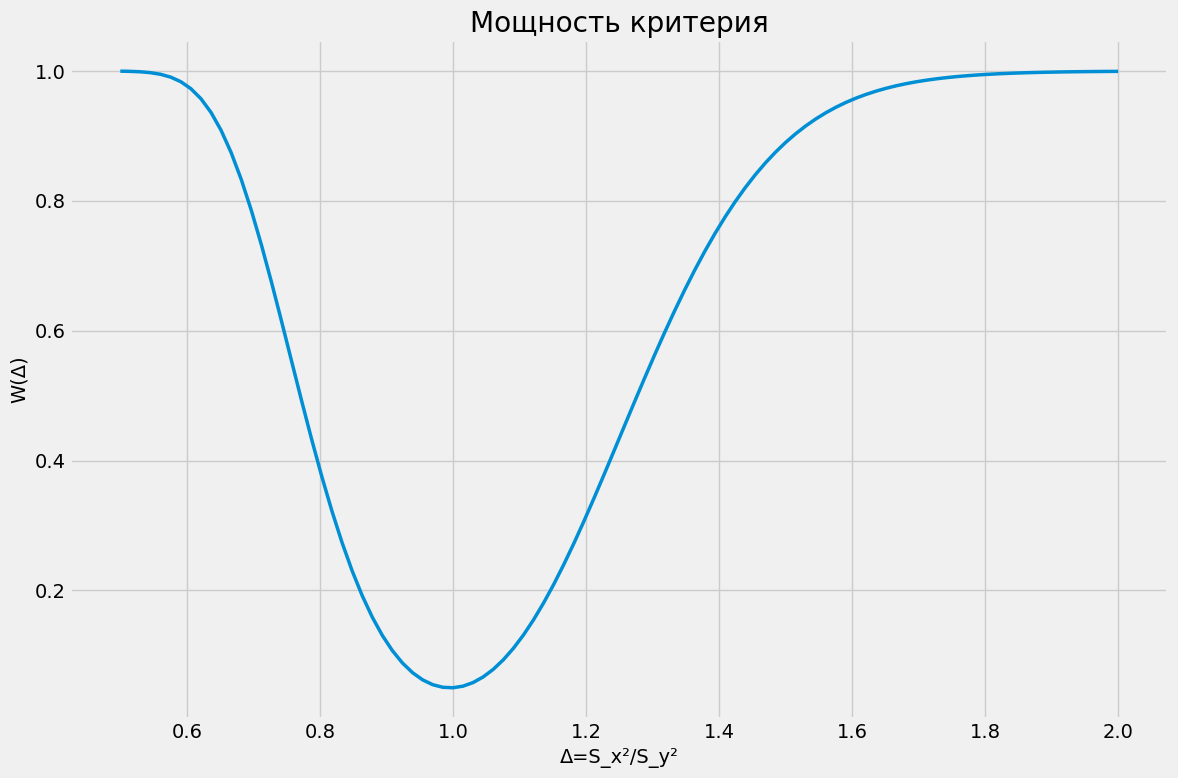

In [25]:
α = 0.05
n, m = 139, 1000

S_x = np.array([5.722, 4.612])
S_y = np.array([6.161, 5.055])

U1 = st.f.ppf(α / 2, n-1, m-1)
U2 = st.f.ppf(1 - α / 2, n-1, m-1)

Δ = (S_x / S_y) ** 2

print(f"Квантили распределения: {U1:.4f}, {U2:.4f}")
print(f"Δ для длины {Δ[0]:.4f} и ширины {Δ[1]:.4f}")

p_value = st.f.sf(Δ, n-1, m-1)
print(f"p_value (для длины) {p_value[0]:.4f}")
print(f"p_value (для ширины) {p_value[1]:.4f}")
print("Поскольку p-value > α, то нет оснований отвергнуть H0")



plt.figure(figsize=(12, 8))

a = np.linspace(0.5, 2, 100)
W = 1 - st.f.cdf(U2, n - 1, m - 1, scale=a) + st.f.cdf(U1, n - 1, m - 1, scale=a)
plt.plot(a, W, linewidth=2.5)


plt.xlabel('Δ=S_x²/S_y²', fontsize=14)
plt.ylabel('W(Δ)', fontsize=14)
plt.title('Мощность критерия')
plt.tight_layout()
plt.show()
